<a href="https://colab.research.google.com/github/Rajeraghav/AI-Engineer-Journey/blob/main/Day02/Placement_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Placement_Data_Full_Class.csv to Placement_Data_Full_Class.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [3]:
df = pd.read_csv("Placement_Data_Full_Class.csv")

print(df.head())

print(df.shape)

print(df.info())

   sl_no gender  ssc_p    ssc_b  hsc_p    hsc_b     hsc_s  degree_p  \
0      1      M  67.00   Others  91.00   Others  Commerce     58.00   
1      2      M  79.33  Central  78.33   Others   Science     77.48   
2      3      M  65.00  Central  68.00  Central      Arts     64.00   
3      4      M  56.00  Central  52.00  Central   Science     52.00   
4      5      M  85.80  Central  73.60  Central  Commerce     73.30   

    degree_t workex  etest_p specialisation  mba_p      status    salary  
0   Sci&Tech     No     55.0         Mkt&HR  58.80      Placed  270000.0  
1   Sci&Tech    Yes     86.5        Mkt&Fin  66.28      Placed  200000.0  
2  Comm&Mgmt     No     75.0        Mkt&Fin  57.80      Placed  250000.0  
3   Sci&Tech     No     66.0         Mkt&HR  59.43  Not Placed       NaN  
4  Comm&Mgmt     No     96.8        Mkt&Fin  55.50      Placed  425000.0  
(215, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Col

In [4]:
print(df.isnull().sum())

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64


In [5]:
df.drop("salary", axis=1, inplace=True)

In [6]:
df['status'] = df['status'].map(
    {
        'Placed':1,
        'Not Placed':0
    }
)

In [7]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [8]:
X = df.drop('status', axis=1)

y = df['status']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy")

print(
    accuracy_score(
        y_test,
        lr_pred
    )
)

Logistic Regression Accuracy
0.8837209302325582


In [11]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy")

print(
    accuracy_score(
        y_test,
        dt_pred
    )
)

Decision Tree Accuracy
0.813953488372093


In [12]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy")

print(
    accuracy_score(
        y_test,
        rf_pred
    )
)

Random Forest Accuracy
0.7674418604651163


In [13]:
print(
    confusion_matrix(
        y_test,
        rf_pred
    )
)

[[ 4  8]
 [ 2 29]]


In [14]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.67      0.33      0.44        12
           1       0.78      0.94      0.85        31

    accuracy                           0.77        43
   macro avg       0.73      0.63      0.65        43
weighted avg       0.75      0.77      0.74        43



In [15]:
rf_prob = rf.predict_proba(X_test)[:,1]

print(
    "ROC AUC Score:",
    roc_auc_score(
        y_test,
        rf_prob
    )
)

ROC AUC Score: 0.8333333333333333


           Feature  Importance
2            ssc_p    0.251519
7         degree_p    0.226206
4            hsc_p    0.174189
12           mba_p    0.095819
0            sl_no    0.066113
10         etest_p    0.061535
9           workex    0.032187
11  specialisation    0.023650
1           gender    0.018934
6            hsc_s    0.014758
3            ssc_b    0.014233
8         degree_t    0.013622
5            hsc_b    0.007236


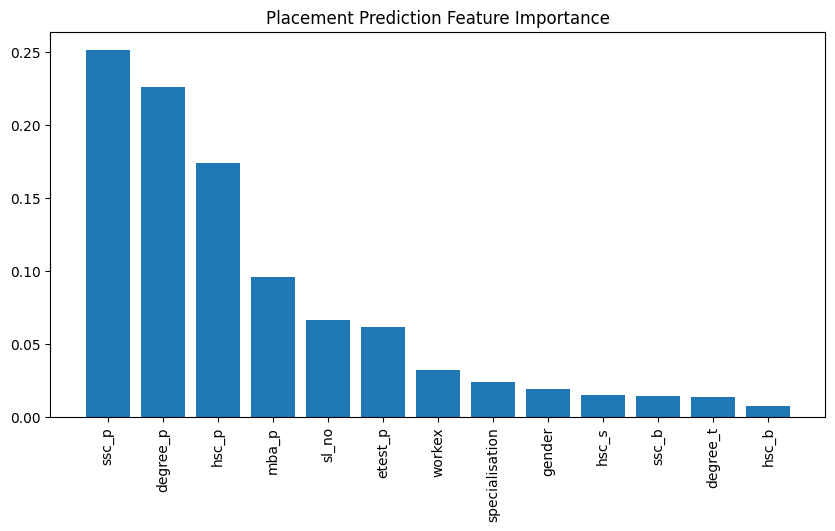

In [16]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10,5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xticks(rotation=90)

plt.title(
    "Placement Prediction Feature Importance"
)

plt.show()